## Final Version

## level label clustering

Dataset shape: (329726, 39)

level_label distribution:
level_label
1     68079
2    201165
3     60482
Name: count, dtype: int64

Selected 4 features for clustering:
  - TcpRtt
  - AckDat
  - IdleTime
  - SynAck

X shape: (329726, 4)
y shape: (329726,)

Train set: 263780 samples
Test set: 65946 samples

MINI-BATCH K-MEANS CLUSTERING (3 CLUSTERS)

Cluster distribution in training set:
  Cluster 0: 108920 samples (41.3%)
  Cluster 1: 119522 samples (45.3%)
  Cluster 2: 35338 samples (13.4%)

Cluster distribution in test set:
  Cluster 0: 27030 samples (41.0%)
  Cluster 1: 29946 samples (45.4%)
  Cluster 2: 8970 samples (13.6%)

CLUSTER TO LABEL MAPPING

Cluster 0:
  Mapped to label: 2
  Label distribution in training:
    Label 1: 12696 samples (11.7%)
    Label 2: 66111 samples (60.7%)
    Label 3: 30113 samples (27.6%)

Cluster 1:
  Mapped to label: 2
  Label distribution in training:
    Label 1: 34286 samples (28.7%)
    Label 2: 75533 samples (63.2%)
    Label 3: 9703 samples (8.1%)

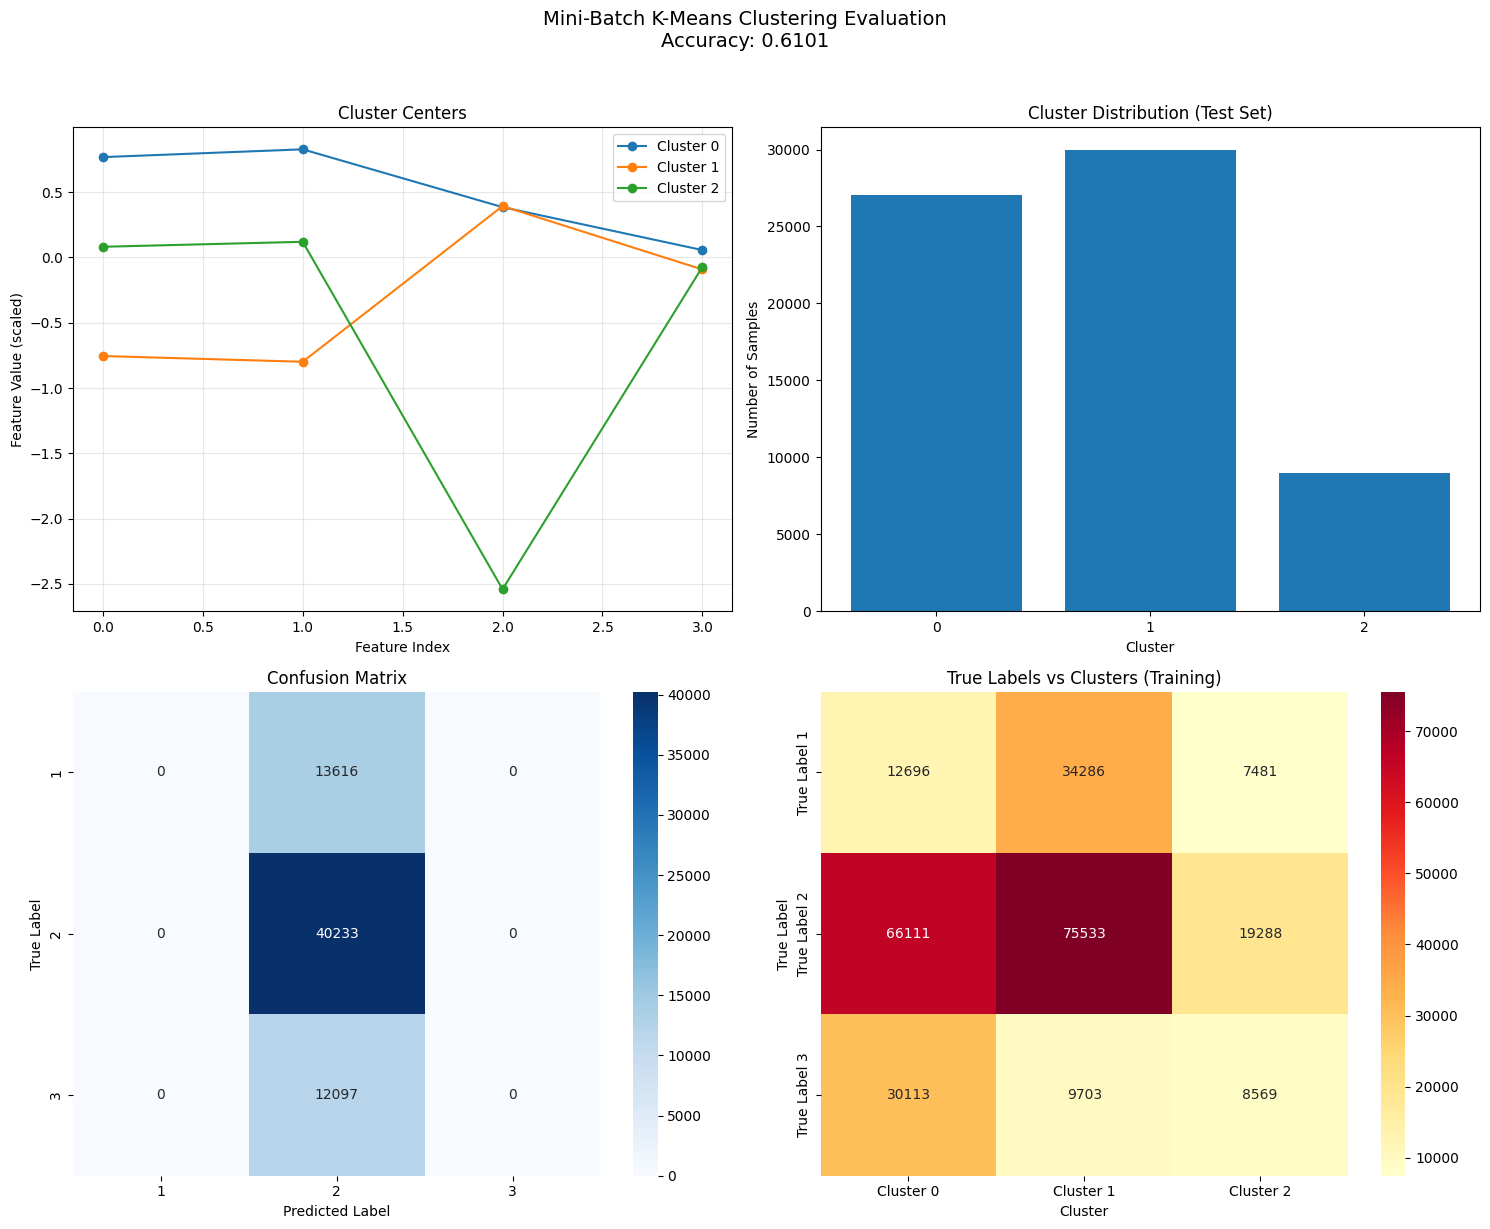

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('DATASETS/CDR-MLC/scale_0.001/Short/CDR-MLC-Shuffle.csv')

print("Dataset shape:", df.shape)
print("\nlevel_label distribution:")
print(df['level_label'].value_counts().sort_index())

# Select features for clustering
selected_features = [
    'TcpRtt',
    'AckDat',
    'IdleTime',
    'SynAck'
]

print(f"\nSelected {len(selected_features)} features for clustering:")
for feat in selected_features:
    print(f"  - {feat}")

# Prepare data
X = df[selected_features].copy()
y = df['level_label']

# Handle missing/infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
if X.isnull().sum().sum() > 0:
    print(f"\nFilling {X.isnull().sum().sum()} missing values with median...")
    X.fillna(X.median(), inplace=True)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Mini-Batch K-Means clustering
print("\n" + "="*60)
print("MINI-BATCH K-MEANS CLUSTERING (3 CLUSTERS)")
print("="*60)

n_clusters = 3
batch_size = 100
mbk = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=batch_size,
    random_state=42,
    n_init=15,
)

# Fit on training data
mbk.fit(X_train_scaled)

# Get cluster labels
train_cluster_labels = mbk.predict(X_train_scaled)
test_cluster_labels = mbk.predict(X_test_scaled)

print(f"\nCluster distribution in training set:")
unique_train, counts_train = np.unique(train_cluster_labels, return_counts=True)
for cluster, count in zip(unique_train, counts_train):
    print(f"  Cluster {cluster}: {count} samples ({count/len(train_cluster_labels)*100:.1f}%)")

print(f"\nCluster distribution in test set:")
unique_test, counts_test = np.unique(test_cluster_labels, return_counts=True)
for cluster, count in zip(unique_test, counts_test):
    print(f"  Cluster {cluster}: {count} samples ({count/len(test_cluster_labels)*100:.1f}%)")

# Map clusters to most common true label in training set
print("\n" + "="*60)
print("CLUSTER TO LABEL MAPPING")
print("="*60)

cluster_label_mapping = {}
for cluster in range(n_clusters):
    cluster_indices = np.where(train_cluster_labels == cluster)[0]
    if len(cluster_indices) > 0:
        true_labels_in_cluster = y_train.iloc[cluster_indices]
        most_common_label = true_labels_in_cluster.mode()[0]
        cluster_label_mapping[cluster] = most_common_label
        
        print(f"\nCluster {cluster}:")
        print(f"  Mapped to label: {most_common_label}")
        print(f"  Label distribution in training:")
        label_counts = true_labels_in_cluster.value_counts().sort_index()
        for label, count in label_counts.items():
            percentage = count / len(true_labels_in_cluster) * 100
            print(f"    Label {label}: {count} samples ({percentage:.1f}%)")

# Predict labels based on cluster mapping
y_pred = np.array([cluster_label_mapping.get(cluster, 0) for cluster in test_cluster_labels])

# Evaluate performance
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, 
                   index=[f'True {i}' for i in sorted(y.unique())],
                   columns=[f'Pred {i}' for i in sorted(y.unique())]))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Cluster centers
cluster_centers = mbk.cluster_centers_
for i in range(n_clusters):
    axes[0, 0].plot(cluster_centers[i], marker='o', label=f'Cluster {i}')
axes[0, 0].set_xlabel('Feature Index')
axes[0, 0].set_ylabel('Feature Value (scaled)')
axes[0, 0].set_title('Cluster Centers')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Cluster distribution
axes[0, 1].bar(range(n_clusters), counts_test)
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Cluster Distribution (Test Set)')
axes[0, 1].set_xticks(range(n_clusters))

# Plot 3: Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()),
            ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_title('Confusion Matrix')

# Plot 4: True labels vs clusters heatmap (training)
cluster_label_matrix = np.zeros((len(np.unique(y)), n_clusters))
for i, true_label in enumerate(sorted(y_train.unique())):
    for j in range(n_clusters):
        mask = (y_train == true_label) & (train_cluster_labels == j)
        cluster_label_matrix[i, j] = mask.sum()

sns.heatmap(cluster_label_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=[f'Cluster {i}' for i in range(n_clusters)],
            yticklabels=[f'True Label {i}' for i in sorted(y_train.unique())],
            ax=axes[1, 1])
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_title('True Labels vs Clusters (Training)')

plt.suptitle(f'Mini-Batch K-Means Clustering Evaluation\nAccuracy: {test_accuracy:.4f}', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## level label calsification

Dataset shape: (329726, 39)

level_label distribution:
level_label
1     68079
2    201165
3     60482
Name: count, dtype: int64

Selected 2 features for classification:
  - TcpRtt
  - AckDat

X shape: (329726, 2)
y shape: (329726,)

Train set: 263780 samples
Test set: 65946 samples

TRAINING RANDOM FOREST CLASSIFIER

Performing 5-fold cross-validation...
Cross-validation accuracy scores: [0.96574797 0.96701797 0.96635454 0.96652513 0.96652513]
Mean CV accuracy: 0.9664 (+/- 0.0008)

MODEL PERFORMANCE

Test Accuracy: 0.9661

Classification Report (Test Set):
              precision    recall  f1-score   support

           1     0.9361    0.9536    0.9448     13616
           2     0.9743    0.9770    0.9757     40233
           3     0.9734    0.9438    0.9584     12097

    accuracy                         0.9661     65946
   macro avg     0.9613    0.9581    0.9596     65946
weighted avg     0.9662    0.9661    0.9661     65946


FEATURE IMPORTANCE

Feature importance:
  TcpRtt: 0.51

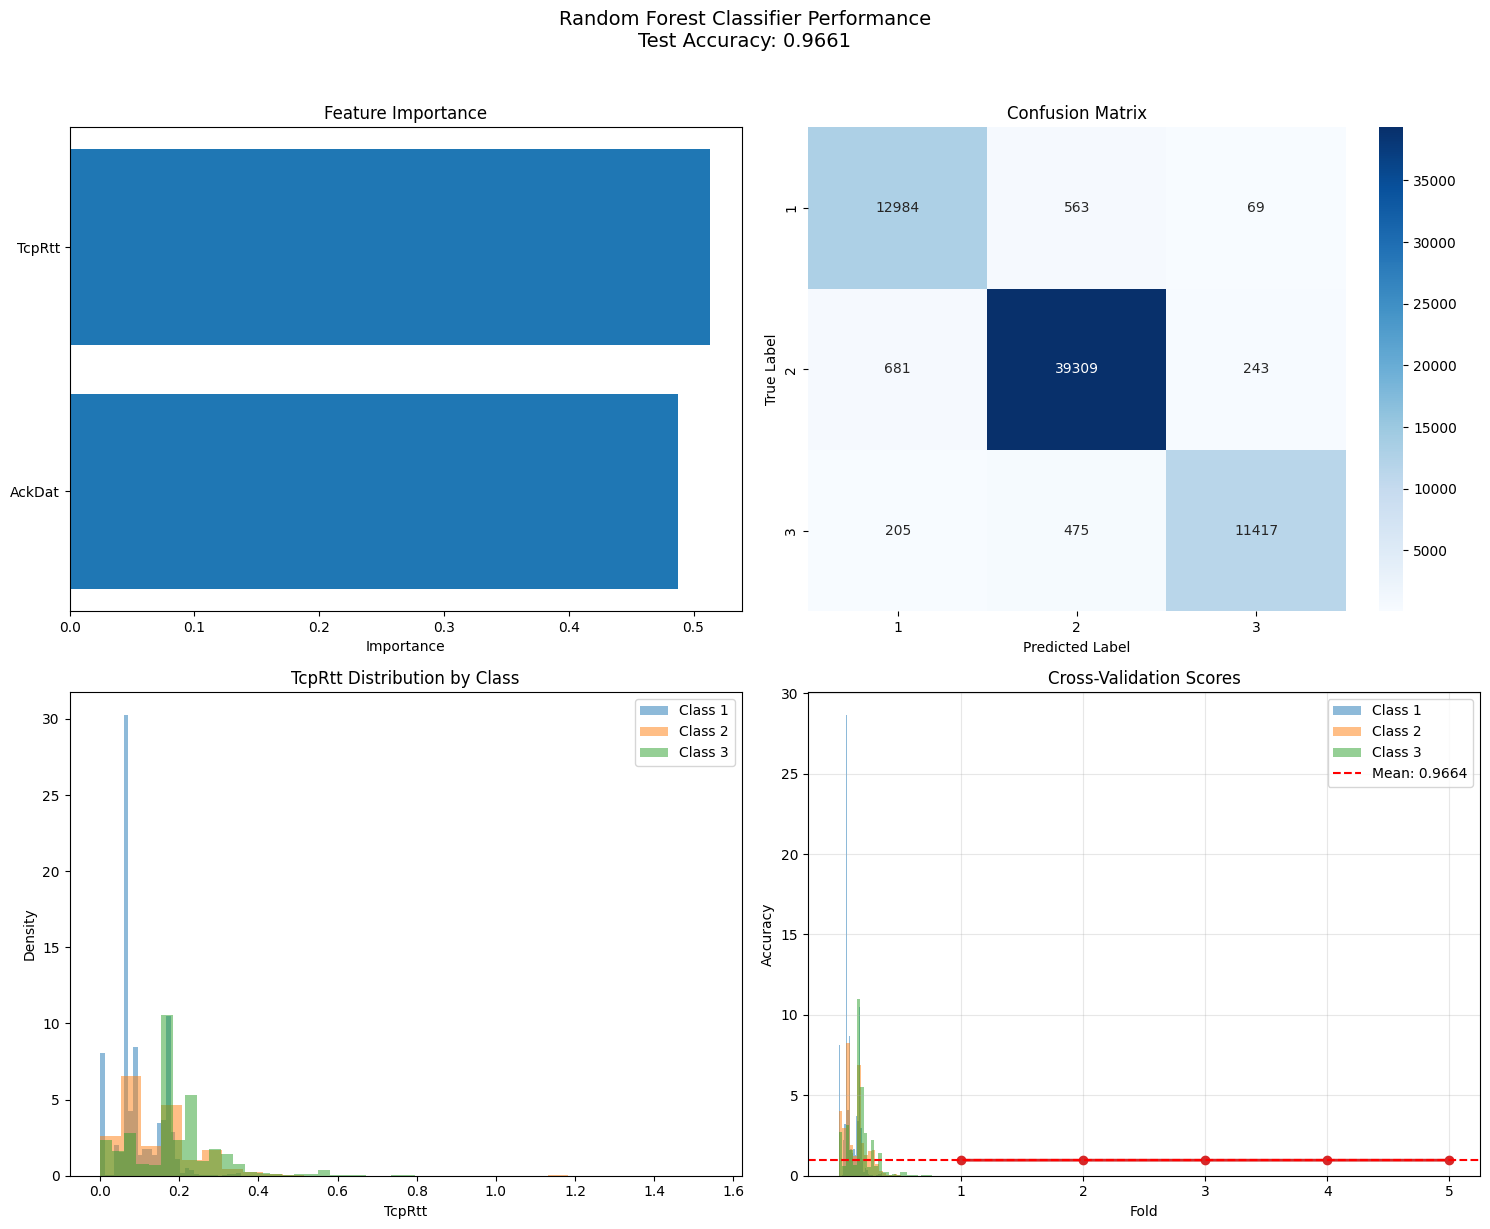

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('DATASETS/CDR-MLC/scale_0.001/Short/CDR-MLC-Shuffle.csv')

print("Dataset shape:", df.shape)
print("\nlevel_label distribution:")
print(df['level_label'].value_counts().sort_index())

# Select features for classification
selected_features = [
    'TcpRtt',       # latency differences
    'AckDat',
    'SynAck',
    'dMeanPktSz',
    'IdleTime'
]

print(f"\nSelected {len(selected_features)} features for classification:")
for feat in selected_features:
    print(f"  - {feat}")

# Prepare data
X = df[selected_features].copy()
y = df['level_label']

# Handle missing/infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
if X.isnull().sum().sum() > 0:
    print(f"\nFilling {X.isnull().sum().sum()} missing values with median...")
    X.fillna(X.median(), inplace=True)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest classifier
print("\n" + "="*60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*60)

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

# Cross-validation
print("\nPerforming 5-fold cross-validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_classifier, X_train_scaled, y_train, 
                           cv=cv, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train on full training set
rf_classifier.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_classifier.predict(X_test_scaled)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Detailed classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=4))

# Feature importance
print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Confusion matrix
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=[f'True {i}' for i in sorted(y.unique())],
                     columns=[f'Pred {i}' for i in sorted(y.unique())])

print("\nConfusion Matrix:")
print(cm_df)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Feature importance
axes[0, 0].barh(feature_importance['feature'], feature_importance['importance'])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Feature Importance')
axes[0, 0].invert_yaxis()

# Plot 2: Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()),
            ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_title('Confusion Matrix')

# Plot 3: Feature distributions by class
for i, feature in enumerate(selected_features[:2]):
    for class_label in sorted(y.unique()):
        class_data = df[df['level_label'] == class_label][feature]
        axes[1, i].hist(class_data, alpha=0.5, label=f'Class {class_label}', 
                       bins=30, density=True)
    axes[1, i].set_xlabel(feature)
    axes[1, i].set_ylabel('Density')
    axes[1, i].set_title(f'{feature} Distribution by Class')
    axes[1, i].legend()

# Plot 4: Cross-validation scores
axes[1, 1].plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2)
axes[1, 1].axhline(y=cv_scores.mean(), color='r', linestyle='--', 
                  label=f'Mean: {cv_scores.mean():.4f}')
axes[1, 1].fill_between(range(1, 6), 
                       cv_scores.mean() - cv_scores.std(),
                       cv_scores.mean() + cv_scores.std(),
                       alpha=0.2, color='gray')
axes[1, 1].set_xlabel('Fold')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Cross-Validation Scores')
axes[1, 1].set_xticks(range(1, 6))
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Random Forest Classifier Performance\nTest Accuracy: {test_accuracy:.4f}', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Load and prepare data
print("=== Loading Data ===")
df = pd.read_csv('DATASETS/CDR-MLC/scale_0.001/Short/CDR-MLC-Shuffle.csv')
df = df.drop(columns=['index_in_label_under_level', 'DstWin', 'IdleTime'])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# 2. Identify numeric features
numeric_features = []
for col in df.columns:
    if col not in ['level_label', 'label'] and pd.api.types.is_numeric_dtype(df[col]):
        numeric_features.append(col)

print(f"\nNumber of numeric features: {len(numeric_features)}")
print(f"Numeric features: {numeric_features}")

# 3. Split data into Train and Test (overall)
X = df[numeric_features]
y_level = df['level_label']  # First level target
y_label = df['label']        # Second level target

# Encode label column
label_encoder = LabelEncoder()
y_label_encoded = label_encoder.fit_transform(y_label)

print(f"\nUnique level_labels: {y_level.unique()}")
print(f"Number of unique labels: {len(label_encoder.classes_)}")
print(f"Label classes: {label_encoder.classes_}")

# Split data
X_train, X_test, y_level_train, y_level_test, y_label_train, y_label_test = train_test_split(
    X, y_level, y_label_encoded, test_size=0.3, random_state=42, stratify=y_level
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# 4. Train first level model (predict level_label)
print("\n=== Training First Level Model (level_label) ===")
rf_level = RandomForestClassifier(n_estimators=100, random_state=42)
rf_level.fit(X_train, y_level_train)

# Predict level_label on test data
y_level_pred = rf_level.predict(X_test)
level_accuracy = accuracy_score(y_level_test, y_level_pred)
level_f1 = f1_score(y_level_test, y_level_pred, average='weighted')

print(f"Level prediction accuracy: {level_accuracy:.4f}")
print(f"Level prediction F1 Score: {level_f1:.4f}")

# 5. Train second level models for each level_label
print("\n=== Training Second Level Models (label) ===")

level_models = {}
label_encoders_by_level = {}

for level in np.unique(y_level_train):
    # Select data for this level from training set
    mask = (y_level_train == level)
    X_train_level = X_train[mask]
    y_label_train_level = y_label_train[mask]
    
    if len(X_train_level) > 0:  # If data exists for this level
        print(f"\nTraining model for level {level} ({len(X_train_level)} samples)")
        print(f"  Unique labels in level {level}: {len(np.unique(y_label_train_level))}")
        
        # Train model for this level
        rf_label = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_label.fit(X_train_level, y_label_train_level)
        
        level_models[level] = rf_label
        print(f"  Model for level {level} trained successfully")

# 6. Overall testing (Two-step prediction)
print("\n=== Overall Testing (Two-step Approach) ===")

all_predictions = []
all_true_labels = []
prediction_details = []  # Store details for analysis

for i in range(len(X_test)):
    # Step 1: Predict level_label
    true_level = y_level_test.iloc[i] if hasattr(y_level_test, 'iloc') else y_level_test[i]
    predicted_level = y_level_pred[i]
    
    # Step 2: Predict label based on predicted level
    true_label = y_label_test[i]
    
    if predicted_level in level_models:
        # Extract features for this sample
        sample_features = X_test.iloc[i:i+1] if hasattr(X_test, 'iloc') else X_test[i:i+1]
        
        # Predict label with appropriate model
        predicted_label = level_models[predicted_level].predict(sample_features)[0]
        prediction_correct = (predicted_label == true_label)
    else:
        # If predicted level wasn't seen in training
        predicted_label = -1
        prediction_correct = False
    
    all_predictions.append(predicted_label)
    all_true_labels.append(true_label)
    
    # Store details for analysis
    prediction_details.append({
        'true_level': true_level,
        'predicted_level': predicted_level,
        'true_label': true_label,
        'predicted_label': predicted_label,
        'level_correct': (true_level == predicted_level),
        'label_correct': prediction_correct
    })

# Calculate evaluation metrics
overall_accuracy = accuracy_score(all_true_labels, all_predictions)
overall_f1 = f1_score(all_true_labels, all_predictions, average='weighted')
overall_precision = precision_score(all_true_labels, all_predictions, average='weighted')
overall_recall = recall_score(all_true_labels, all_predictions, average='weighted')

print(f"\nOverall Test Results (Two-step Approach):")
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Overall F1 Score: {overall_f1:.4f}")
print(f"Overall Precision: {overall_precision:.4f}")
print(f"Overall Recall: {overall_recall:.4f}")

# 7. Comparison with direct model (without hierarchy)
print("\n=== Comparison with Direct Model (No Hierarchy) ===")
rf_direct = RandomForestClassifier(n_estimators=100, random_state=42)
rf_direct.fit(X_train, y_label_train)
y_direct_pred = rf_direct.predict(X_test)

direct_accuracy = accuracy_score(y_label_test, y_direct_pred)
direct_f1 = f1_score(y_label_test, y_direct_pred, average='weighted')
direct_precision = precision_score(y_label_test, y_direct_pred, average='weighted')
direct_recall = recall_score(y_label_test, y_direct_pred, average='weighted')

print(f"Direct Model Accuracy: {direct_accuracy:.4f}")
print(f"Direct Model F1 Score: {direct_f1:.4f}")
print(f"Direct Model Precision: {direct_precision:.4f}")
print(f"Direct Model Recall: {direct_recall:.4f}")

# 8. Error analysis
print("\n=== Error Analysis ===")

# Convert prediction details to DataFrame for analysis
details_df = pd.DataFrame(prediction_details)

# Level prediction accuracy
level_accuracy_test = details_df['level_correct'].mean()
print(f"\nLevel Prediction Accuracy on Test Set: {level_accuracy_test:.4f}")

# Label prediction accuracy when level is correct vs incorrect
correct_level_mask = details_df['level_correct'] == True
if correct_level_mask.any():
    label_acc_when_level_correct = details_df.loc[correct_level_mask, 'label_correct'].mean()
    print(f"Label Accuracy when Level is Correct: {label_acc_when_level_correct:.4f}")

if (~correct_level_mask).any():
    label_acc_when_level_incorrect = details_df.loc[~correct_level_mask, 'label_correct'].mean()
    print(f"Label Accuracy when Level is Incorrect: {label_acc_when_level_incorrect:.4f}")

# Confusion matrix for level_label
print("\nConfusion Matrix for level_label:")
cm_level = confusion_matrix(y_level_test, y_level_pred)
print(cm_level)

# Classification report for label (two-step approach)
print("\nClassification Report for label (Two-step Approach):")
print(classification_report(all_true_labels, all_predictions, 
                           target_names=label_encoder.classes_))

# 9. Performance analysis by level
print("\n=== Performance Analysis by Level ===")
for level in np.unique(y_level_test):
    if hasattr(y_level_test, 'iloc'):
        mask = (y_level_test == level)
    else:
        mask = (y_level_test == level)
    
    if sum(mask) > 0:
        level_indices = np.where(mask)[0]
        level_true_labels = [all_true_labels[i] for i in level_indices]
        level_pred_labels = [all_predictions[i] for i in level_indices]
        
        if len(level_true_labels) > 0:
            level_accuracy = accuracy_score(level_true_labels, level_pred_labels)
            level_count = sum(mask)
            print(f"Level {level}: {level_count} samples, Accuracy: {level_accuracy:.4f}")

# 10. Feature importance analysis
print("\n=== Feature Importance Analysis ===")
feature_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': rf_level.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features for level prediction:")
print(feature_importance.head(10))

# 11. Summary statistics
print("\n=== Summary Statistics ===")
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of level_labels: {len(np.unique(y_level))}")
print(f"Number of unique labels: {len(label_encoder.classes_)}")
print(f"\nTwo-step Approach Accuracy: {overall_accuracy:.4f}")
print(f"Direct Approach Accuracy: {direct_accuracy:.4f}")
print(f"Improvement: {(overall_accuracy - direct_accuracy):.4f}")

# 12. Save results to file
results = {
    'two_step_accuracy': overall_accuracy,
    'two_step_f1': overall_f1,
    'two_step_precision': overall_precision,
    'two_step_recall': overall_recall,
    'direct_accuracy': direct_accuracy,
    'direct_f1': direct_f1,
    'direct_precision': direct_precision,
    'direct_recall': direct_recall,
    'level_accuracy': level_accuracy_test,
    'num_levels': len(np.unique(y_level)),
    'num_labels': len(label_encoder.classes_)
}

results_df = pd.DataFrame([results])
results_df.to_csv('hierarchical_classification_results.csv', index=False)
print("\nResults saved to 'hierarchical_classification_results.csv'")

=== Loading Data ===
Dataset shape: (329726, 36)
Columns: ['pRetran', 'SrcRetra', 'PCRatio', 'SrcWin', 'SrcLoss', 'DstRate', 'SrcLoad', 'Load', 'DstLoad', 'TcpRtt', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'Dur', 'SrcPkts', 'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'TotPkts', 'DstPkts', 'Mean', 'SrcBytes', 'TotBytes', 'dMeanPktSz', 'DstRetra', 'SynAck', 'label', 'level_label']

Number of numeric features: 34
Numeric features: ['pRetran', 'SrcRetra', 'PCRatio', 'SrcWin', 'SrcLoss', 'DstRate', 'SrcLoad', 'Load', 'DstLoad', 'TcpRtt', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'Dur', 'SrcPkts', 'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'TotPkts', 'DstPkts', 'Mean', 'SrcBytes', 'TotBytes', 'dMeanPktSz', 'DstRetra', 'SynAck']

Unique level_labels: [3 1 2]
Number of unique labels: 5
Label classes: ['HTTP' 'SFTP' 'SMTP' 'SSH' 'VIDEO']

Training samples: 230808
Test samples: 98918

=== Training First Level

## Test 

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Configuration
TEST_CSV_PATH = 'DATASETS/CDR-MLC/scale_0.001/Long/CDR-MLC-Shuffle.csv'  # Path to your test CSV
NUM_SAMPLES = 10  # Number of times to sample
SAMPLE_SIZE = 2000  # Size of each sample

# Load test data
print("Loading test data...")
test_df = pd.read_csv(TEST_CSV_PATH)
test_df = test_df.drop(columns=['index_in_label', 'level_label', 'IdleTime', 'DstWin'], errors='ignore')

# Identify numeric features (same as training)
numeric_features = []
for col in test_df.columns:
    if col != 'label' and pd.api.types.is_numeric_dtype(test_df[col]):
        numeric_features.append(col)

print(f"Test dataset shape: {test_df.shape}")
print(f"Number of test samples: {len(test_df)}")
print(f"Numeric features: {numeric_features}")

# Prepare test data
X_test_all = test_df[numeric_features]
y_label_test_all = test_df['label']

# Encode labels (use same encoder from training or create new one)
label_encoder = LabelEncoder()
y_label_test_encoded_all = label_encoder.fit_transform(y_label_test_all)

# Initialize results storage
all_results = []

# Perform multiple sampling tests
for sample_num in range(1, NUM_SAMPLES + 1):
    print(f"\n--- Sample Test {sample_num}/{NUM_SAMPLES} ---")
    
    # Random sampling
    if len(test_df) > SAMPLE_SIZE:
        sample_indices = np.random.choice(len(test_df), SAMPLE_SIZE, replace=False)
    else:
        sample_indices = np.arange(len(test_df))
        print(f"Warning: Sample size ({SAMPLE_SIZE}) larger than dataset ({len(test_df)}). Using all data.")
    
    X_test = X_test_all.iloc[sample_indices]
    y_label_test = y_label_test_encoded_all[sample_indices]
    
    # Two-step prediction
    predictions = []
    true_labels = []
    
    # Step 1: Predict level_label using first level model
    y_level_pred = rf_level.predict(X_test)
    
    # Step 2: Predict label based on predicted level
    for i in range(len(X_test)):
        predicted_level = y_level_pred[i]
        true_label = y_label_test[i]
        
        if predicted_level in level_models:
            sample_features = X_test.iloc[i:i+1]
            predicted_label = level_models[predicted_level].predict(sample_features)[0]
        else:
            predicted_label = -1
        
        predictions.append(predicted_label)
        true_labels.append(true_label)
    
    # Calculate metrics for this sample
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='weighted')
    prec = precision_score(true_labels, predictions, average='weighted')
    rec = recall_score(true_labels, predictions, average='weighted')
    
    # Store results
    sample_results = {
        'sample_num': sample_num,
        'sample_size': len(X_test),
        'accuracy': acc,
        'f1_score': f1,
        'precision': prec,
        'recall': rec
    }
    all_results.append(sample_results)
    
    print(f"Sample {sample_num} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")

# Calculate average metrics
print("\n" + "="*50)
print("FINAL AVERAGE RESULTS")
print("="*50)

avg_accuracy = np.mean([r['accuracy'] for r in all_results])
avg_f1 = np.mean([r['f1_score'] for r in all_results])
avg_precision = np.mean([r['precision'] for r in all_results])
avg_recall = np.mean([r['recall'] for r in all_results])

std_accuracy = np.std([r['accuracy'] for r in all_results])
std_f1 = np.std([r['f1_score'] for r in all_results])
std_precision = np.std([r['precision'] for r in all_results])
std_recall = np.std([r['recall'] for r in all_results])

print(f"\nAverage over {NUM_SAMPLES} samples (size: {SAMPLE_SIZE}):")
print(f"Accuracy:  {avg_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"F1 Score:  {avg_f1:.4f} ± {std_f1:.4f}")
print(f"Precision: {avg_precision:.4f} ± {std_precision:.4f}")
print(f"Recall:    {avg_recall:.4f} ± {std_recall:.4f}")

# Save detailed results to CSV
results_df = pd.DataFrame(all_results)
results_df.to_csv('hierarchical_sampling_test_results.csv', index=False)
print(f"\nDetailed results saved to 'hierarchical_sampling_test_results.csv'")

# Display results table
print("\nDetailed Results Table:")
print(results_df.to_string(index=False))

Loading test data...
Test dataset shape: (1417001, 35)
Number of test samples: 1417001
Numeric features: ['pRetran', 'SrcRetra', 'PCRatio', 'SrcWin', 'SrcLoss', 'DstRate', 'SrcLoad', 'Load', 'DstLoad', 'TcpRtt', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'Dur', 'SrcPkts', 'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'TotPkts', 'DstPkts', 'Mean', 'SrcBytes', 'TotBytes', 'dMeanPktSz', 'DstRetra', 'SynAck']

--- Sample Test 1/10 ---
Sample 1 Results:
  Accuracy: 0.7550
  F1 Score: 0.7320
  Precision: 0.8016
  Recall: 0.7550

--- Sample Test 2/10 ---
Sample 2 Results:
  Accuracy: 0.7235
  F1 Score: 0.6960
  Precision: 0.7633
  Recall: 0.7235

--- Sample Test 3/10 ---
Sample 3 Results:
  Accuracy: 0.7325
  F1 Score: 0.7077
  Precision: 0.7776
  Recall: 0.7325

--- Sample Test 4/10 ---
Sample 4 Results:
  Accuracy: 0.7540
  F1 Score: 0.7294
  Precision: 0.8000
  Recall: 0.7540

--- Sample Test 5/10 ---
Sample 5 Results:
  Accuracy: 0.7410
  F1 Score: 